In [95]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erf
from numpy import exp
from numpy.lib.scimath import log, sqrt

In [96]:
file_path = "outputs/"

# Exercise 3:  Estimating the Price of European Options

The goal of this exercise is to estimate the price of a European call or put option. Under the hypothesis of an ideal market, there are two primary numerical approaches to calculating this price.

1. **Black-Scholes** analytical solution;
2. **Montecarlo Simulations** of the evolution of the price with time.

In the following sections, I present the results of the Monte Carlo simulations using both the direct method and the discretized path sampling. These numerical estimates are compared directly against the analytical Black-Scholes expectations. To ensure statistically rigorous uncertainties, I implement the data blocking method, demonstrating that the simulated prices successfully converge to the expected theoretical values.

## Black-Scholes equation

The **Black-Scholes theory** provides an analytical solution to this problem. It assumes that the market is perfectly efficient (meaning it has infinite liquidity, zero friction, and exhibits Markovian properties). Furthermore, it assumes that the spot price of the underlying asset follows a Geometric Brownian Motion (GBM) with a constant risk-free interest rate $r$ and volatility $\sigma$. Under these strict assumptions, the fair price of an option today is determined exactly by the Black-Scholes equation.

In [97]:
# Data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

# Print results
expected_call_price, expected_put_price = black_scholes(S0, K, T, r, sigma)
print("===== BLACK-SCHOLES =====")
print("Call-option price:\t", expected_call_price)
print("Put-option price:\t", expected_put_price)

===== BLACK-SCHOLES =====
Call-option price:	 14.975790778311286
Put-option price:	 5.4595325819072364


## Monte Carlo Simulations

However, real-world markets are rarely perfectly efficient; they exhibit long-term correlations, volatility clustering, and return distributions that deviate from the strict GBM hypothesis. When these idealized assumptions break down, or when pricing more complex exotic options, analytical solutions like Black-Scholes fail.

**Monte Carlo simulations** provide a robust numerical alternative in these situations. By knowing the probability distribution that governs the spot price increments, we can simulate thousands of possible asset price paths up to the expiry date to determine the option's fair expected value today. For standard European options, Geometric Brownian Motion remains the distribution of choice for modeling the underlying asset.

### The Direct Sampling Method

Because the analytical properties of GBM are known, we do not strictly need to simulate the day-to-day evolution of the price for a plain vanilla European option. Instead, we can "fast-forward" directly to the expiry date $T$. We simulate the final asset price, calculate the resulting profit of the option, and then discount that profit back to the present value using the risk-free discount factor $e^{-rT}$. In a risk-neutral pricing framework, the asset drift $\mu$ is replaced by the risk-free interest rate $r$. Given a random variable $Z_i \sim \mathcal{N}(0,1)$, the final spot price for simulation $i$ is directly sampled as:

$$S_i(T) = S(0) \exp\left[ \left(r - \frac{\sigma^2}{2}\right)T + \sigma Z_i \sqrt{T} \right]$$


In [98]:
throws, blocks, call_price_direct, error_call_price_direct, put_price_direct, error_put_price_direct = np.loadtxt(file_path + "output_direct_03.dat", unpack=True)

#### Call-option (direct)

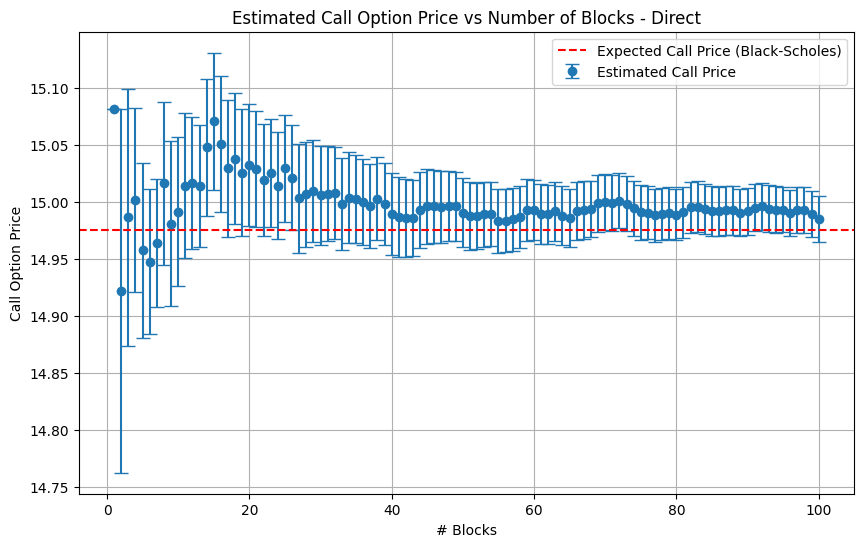

In [99]:
plt.figure(figsize=(10, 6))
plt.errorbar(blocks, call_price_direct, yerr=error_call_price_direct, fmt='o', label='Estimated Call Price', capsize=5)
plt.axhline(expected_call_price, color='r', linestyle='--', label='Expected Call Price (Black-Scholes)')
plt.xlabel('# Blocks')
plt.ylabel('Call Option Price')
plt.title('Estimated Call Option Price vs Number of Blocks - Direct')
plt.legend()
plt.grid()
plt.show()

#### Put-option (direct)

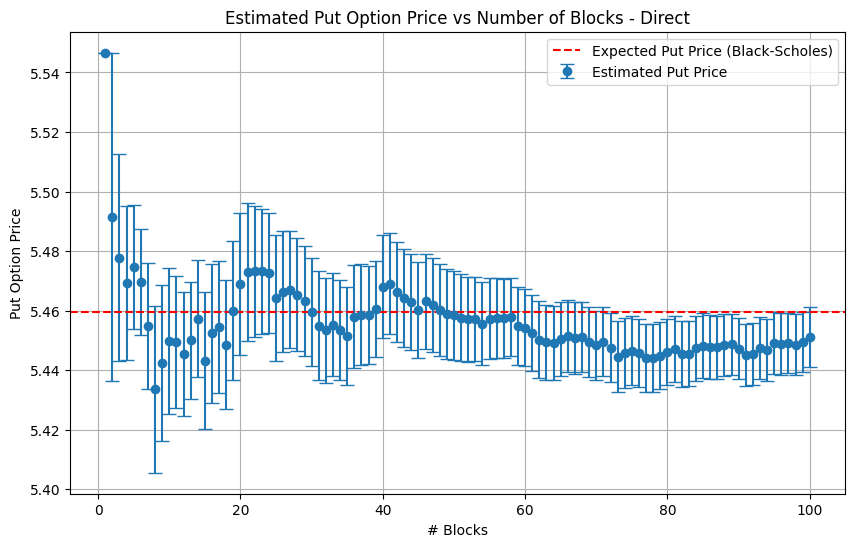

In [100]:
plt.figure(figsize=(10, 6))
plt.errorbar(blocks, put_price_direct, yerr=error_put_price_direct, fmt='o', label='Estimated Put Price', capsize=5)
plt.axhline(expected_put_price, color='r', linestyle='--', label='Expected Put Price (Black-Scholes)')
plt.xlabel('# Blocks')
plt.ylabel('Put Option Price')
plt.title('Estimated Put Option Price vs Number of Blocks - Direct')
plt.legend()
plt.grid()
plt.show()

### The Discretized Path Sampling Method

For more complex derivatives (like Asian or Lookback options), the payoff depends on the entire trajectory, making step-by-step sampling necessary. Even though it is not strictly required for a European option, we can divide the time interval $[0,T]$ into discrete steps to reconstruct the path. For GBM, this approach is still exact; there is no discretization error because the probability distribution of the simulated points matches the continuous process perfectly on the discrete time grid. Using standard normal increments $Z_{i+1} \sim \mathcal{N}(0,1)$, the asset price evolves recursively step-by-step as:

$$S(t_{i+1}) = S(t_i) \exp\left[ \left(r - \frac{\sigma^2}{2}\right)(t_{i+1} - t_i) + \sigma Z_{i+1} \sqrt{t_{i+1} - t_i} \right]$$

In [101]:
throws, blocks, call_price_sampling, error_call_price_sampling, put_price_sampling, error_put_price_sampling = np.loadtxt(file_path + "output_trajectory_03.dat", unpack=True)

#### Call-option (Sampling)

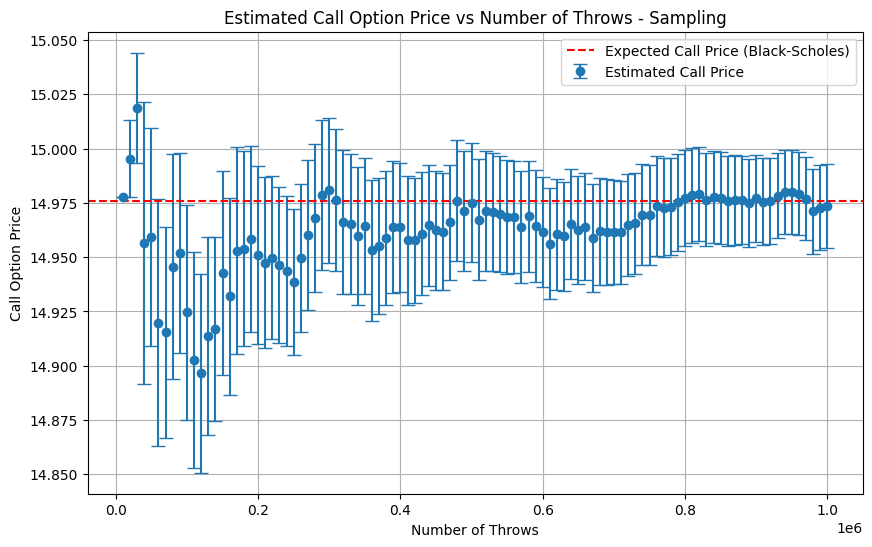

In [102]:
plt.figure(figsize=(10, 6))
plt.errorbar(throws, call_price_sampling, yerr=error_call_price_sampling, fmt='o', label='Estimated Call Price', capsize=5)
plt.axhline(expected_call_price, color='r', linestyle='--', label='Expected Call Price (Black-Scholes)')
plt.xlabel('Number of Throws')
plt.ylabel('Call Option Price')
plt.title('Estimated Call Option Price vs Number of Throws - Sampling')
plt.legend()
plt.grid()
plt.show()

#### Put-option (Sampling)

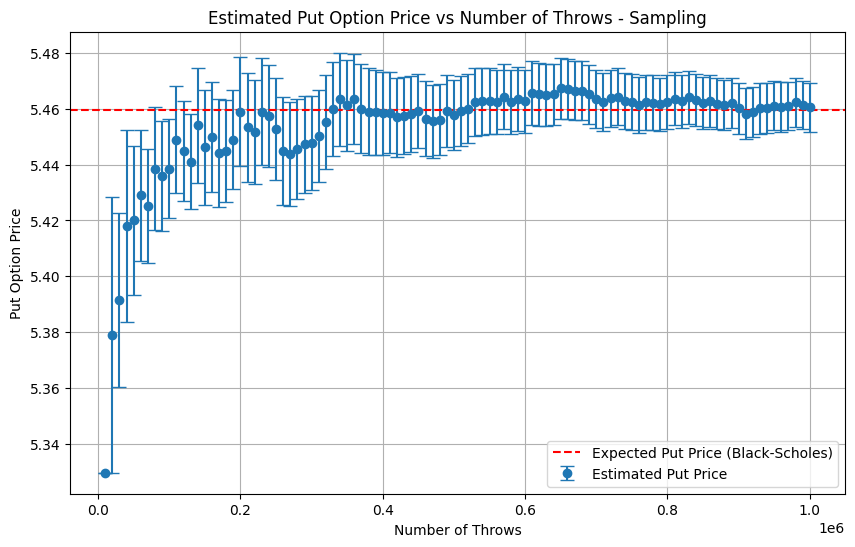

In [103]:
plt.figure(figsize=(10, 6))
plt.errorbar(throws, put_price_sampling, yerr=error_put_price_sampling, fmt='o', label='Estimated Put Price', capsize=5)
plt.axhline(expected_put_price, color='r', linestyle='--', label='Expected Put Price (Black-Scholes)')
plt.xlabel('Number of Throws')
plt.ylabel('Put Option Price')
plt.title('Estimated Put Option Price vs Number of Throws - Sampling')
plt.legend()
plt.grid()
plt.show()